In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Load the dataset
data = pd.read_csv('techSalaries2017.csv')
data.head()

,company,title,location,totalyearlycompensation,basesalary,stockgrantvalue,bonus,yearsofexperience,yearsatcompany,gender,...,Race_Two_Or_More,Race_Black,Race_Hispanic,Race,Education,Age,Height,Zodiac,SAT,GPA
0,Oracle,Product Manager,"Redwood City, CA",127000,107000,20000.0,10000.0,1.5,1.5,NaN,...,0,0,0,NaN,NaN,38,68.590,5,829,2.13
1,eBay,Software Engineer,"San Francisco, CA",100000,0,0.0,0.0,5.0,3.0,NaN,...,0,0,0,NaN,NaN,34,68.059,7,993,2.77
2,Amazon,Product Manager,"Seattle, WA",310000,155000,0.0,0.0,8.0,0.0,NaN,...,0,0,0,NaN,NaN,42,61.343,3,1200,3.26
3,Apple,Software Engineering Manager,"Sunnyvale, CA",372000,157000,180000.0,35000.0,7.0,5.0,NaN,...,0,0,0,NaN,NaN,28,66.495,3,1170,3.07
4,Microsoft,Software Engineer,"Mountain View, CA",157000,0,0.0,0.0,5.0,3.0,NaN,...,0,0,0,NaN,NaN,34,69.015,2,1115,2.91


In [2]:
# Question 1

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

data = pd.read_csv('techSalaries2017.csv')

# clearing the data that has incomplete information
data.dropna(subset=['totalyearlycompensation', 'yearsofexperience', 'yearsatcompany', 'Masters_Degree', 'Bachelors_Degree', 
                    'Doctorate_Degree', 'Highschool', 'Some_College', 'Race_Asian', 'Race_White', 
                    'Race_Two_Or_More', 'Race_Black', 'Race_Hispanic', 'Age', 'Height', 'Zodiac', 
                    'SAT', 'GPA', 'gender'], inplace=True)

# dummy variables
gender_dummy = pd.get_dummies(data['gender'], prefix='gender', drop_first=True)
data = pd.concat([data, gender_dummy], axis=1)
data.drop('gender', axis=1, inplace=True)


X = data[['yearsofexperience', 'yearsatcompany', 'Masters_Degree',
          'Bachelors_Degree', 'Doctorate_Degree', 'Highschool',
          'Some_College', 'Race_Asian', 'Race_White', 'Race_Two_Or_More',
          'Race_Black', 'Race_Hispanic', 'Age', 'Height', 'Zodiac',
          'SAT', 'GPA', 'gender_Male', 'gender_Other']]  
y = data['totalyearlycompensation']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2_overall = r2_score(y_test, y_pred)

best_predictor = None
best_r2 = -1 

print("Respective R-squared values:")
print("")
for feature in X.columns:
    feature_model = LinearRegression()
    feature_model.fit(X_train[[feature]], y_train)
    y_pred_feature = feature_model.predict(X_test[[feature]])
    r2_feature = r2_score(y_test, y_pred_feature)
    print(feature, "->", r2_feature)
    if r2_feature > best_r2:
        best_r2 = r2_feature
        best_predictor = feature

print("")
print("")

print('Best Predictor:', best_predictor)
print('R^2 for the best predictor model:', best_r2)
print('R^2 for the full multiple regression model:', r2_overall)

Respective R-squared values:

yearsofexperience -> 0.16350815793233253
yearsatcompany -> 0.03053493464127577
Masters_Degree -> -0.00020649943929984538
Bachelors_Degree -> 0.01648965407076275
Doctorate_Degree -> 0.010710700718807531
Highschool -> 3.241021637578889e-05
Some_College -> -0.0004807247767524281
Race_Asian -> 0.004091942579802721
Race_White -> -0.0002698719053904064
Race_Two_Or_More -> -0.0004277072034073459
Race_Black -> 0.000528359592620764
Race_Hispanic -> 1.143725532326556e-05
Age -> 0.06412677475922435
Height -> -0.0004960671695442009
Zodiac -> -0.0004786146330713059
SAT -> 0.10317411688764178
GPA -> 0.08407942958435444
gender_Male -> 0.0007877660697512834
gender_Other -> -0.0002415626845622132


Best Predictor: yearsofexperience
R^2 for the best predictor model: 0.16350815793233253
R^2 for the full multiple regression model: 0.25234481183993795


OLS R^2 Score: 0.25234481183993795
Ridge Regression R^2 Score: 0.25232387032578985
Optimal Lambda for Ridge Regression: 10


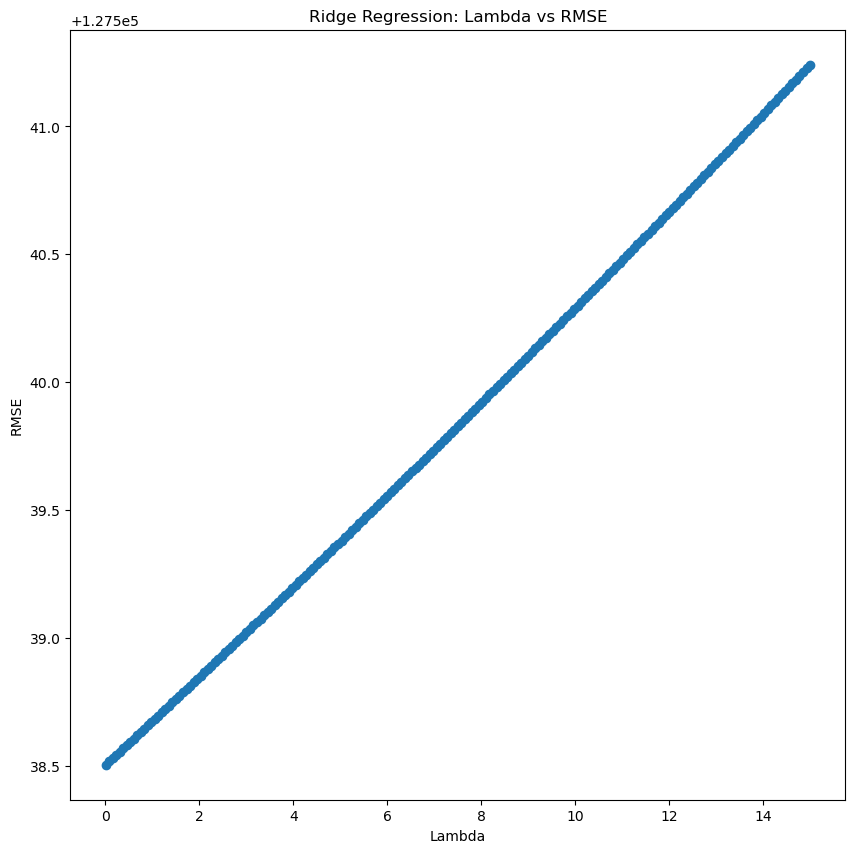

In [9]:
# Question 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import GridSearchCV

data = pd.read_csv('techSalaries2017.csv')

data.dropna(subset=['totalyearlycompensation','yearsofexperience', 'yearsatcompany', 'Masters_Degree', 'Bachelors_Degree', 
                    'Doctorate_Degree', 'Highschool', 'Some_College', 'Race_Asian', 'Race_White', 
                    'Race_Two_Or_More', 'Race_Black', 'Race_Hispanic', 'Age', 'Height', 'Zodiac', 
                    'SAT', 'GPA', 'gender'], inplace=True)

gender_dummy = pd.get_dummies(data['gender'], prefix='gender', drop_first=True)
data = pd.concat([data, gender_dummy], axis=1)
data.drop('gender', axis=1, inplace=True)

X = data[['yearsofexperience', 'yearsatcompany', 'Masters_Degree',
          'Bachelors_Degree', 'Doctorate_Degree', 'Highschool',
          'Some_College', 'Race_Asian', 'Race_White', 'Race_Two_Or_More',
          'Race_Black', 'Race_Hispanic', 'Age', 'Height', 'Zodiac',
          'SAT', 'GPA', 'gender_Male', 'gender_Other']]  
y = data['totalyearlycompensation']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


ridge_model = Ridge()
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10]}  
ridge_grid_search = GridSearchCV(ridge_model, param_grid, cv=5, scoring='r2')
ridge_grid_search.fit(X_train, y_train)

optimal_lambda = ridge_grid_search.best_params_['alpha']

ridge_model = Ridge(alpha=optimal_lambda)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
r2_ridge = ridge_model.score(X_test, y_test)

lambdas = np.linspace(0.001, 15, 201)
rmses = []
for lam in lambdas:
    ridge_model = Ridge(alpha=lam)
    ridge_model.fit(X_train, y_train)
    y_pred_ridge = ridge_model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred_ridge, squared=False)
    rmses.append(rmse)


ols_model = LinearRegression()
ols_model.fit(X_train, y_train)
y_pred_ols = ols_model.predict(X_test)
r2_ols = r2_score(y_test, y_pred_ols)    
    
print("OLS R^2 Score:", r2_ols)
print("Ridge Regression R^2 Score:", r2_ridge)
print("Optimal Lambda for Ridge Regression:", optimal_lambda)    
    
plt.figure(figsize=(10, 10))
plt.plot(lambdas, rmses, marker='o')
plt.xlabel('Lambda')
plt.ylabel('RMSE')
plt.title('Ridge Regression: Lambda vs RMSE')
plt.show()




In [4]:
# Question 3

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score, mean_squared_error

data = pd.read_csv('techSalaries2017.csv')

data.dropna(subset=['totalyearlycompensation','yearsofexperience', 'yearsatcompany', 'Masters_Degree', 'Bachelors_Degree', 
                    'Doctorate_Degree', 'Highschool', 'Some_College', 'Race_Asian', 'Race_White', 
                    'Race_Two_Or_More', 'Race_Black', 'Race_Hispanic', 'Age', 'Height', 'Zodiac', 
                    'SAT', 'GPA', 'gender'], inplace=True)

gender_dummy = pd.get_dummies(data['gender'], prefix='gender', drop_first=True)
data = pd.concat([data, gender_dummy], axis=1)
data.drop('gender', axis=1, inplace=True)

X = data[['yearsofexperience', 'yearsatcompany', 'Masters_Degree',
          'Bachelors_Degree', 'Doctorate_Degree', 'Highschool',
          'Some_College', 'Race_Asian', 'Race_White', 'Race_Two_Or_More',
          'Race_Black', 'Race_Hispanic', 'Age', 'Height', 'Zodiac',
          'SAT', 'GPA', 'gender_Male', 'gender_Other']]
y = data['totalyearlycompensation']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

lasso_model = Lasso()
lasso_grid_search = GridSearchCV(lasso_model, param_grid, cv=5, scoring='r2')
lasso_grid_search.fit(X_train, y_train)
optimal_lambda = lasso_grid_search.best_params_['alpha']

lasso_model = Lasso(alpha=optimal_lambda)
lasso_model.fit(X_train, y_train)
y_pred = lasso_model.predict(X_test)


mse_full_model = mean_squared_error(y_test, y_pred)
r2_full_model = r2_score(y_test, y_pred)

num_zero_coefs = sum(lasso_model.coef_ == 0)
lasso_coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': lasso_model.coef_})
print(lasso_coefficients)

print("")
print('Number of coefficients shrunk to exactly 0:', num_zero_coefs)
print('R^2 for the full Lasso regression model:', r2_full_model)
print('Optimal lambda for Lasso regression:', optimal_lambda)


              Feature   Coefficient
0   yearsofexperience   9261.581577
1      yearsatcompany  -2706.132637
2      Masters_Degree    289.489678
3    Bachelors_Degree -22093.039951
4    Doctorate_Degree  68800.828355
5          Highschool -28866.492160
6        Some_College -27400.800194
7          Race_Asian -13867.267675
8          Race_White -11974.255945
9    Race_Two_Or_More   2578.597644
10         Race_Black -14261.702390
11      Race_Hispanic -17928.638943
12                Age   -137.816155
13             Height    -22.456918
14             Zodiac    203.585248
15                SAT    315.210844
16                GPA     -2.965625
17        gender_Male   3949.517102
18       gender_Other  22343.320194

Number of coefficients shrunk to exactly 0: 0
R^2 for the full Lasso regression model: 0.25233763680895416
Optimal lambda for Lasso regression: 10


In [5]:
# Question 4

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

data = pd.read_csv('techSalaries2017.csv')

X = data[['totalyearlycompensation', 'yearsofexperience', 'yearsatcompany', 'Masters_Degree',
          'Bachelors_Degree', 'Doctorate_Degree', 'Highschool',
          'Some_College', 'Race_Asian', 'Race_White', 'Race_Two_Or_More',
          'Race_Black', 'Race_Hispanic', 'Age', 'Height', 'Zodiac',
          'SAT', 'GPA']]

y = (data['gender'] == 'Male').astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

no_control = LogisticRegression()
no_control.fit(X_train[['totalyearlycompensation']], y_train)

y_no_control = no_control.predict(X_test[['totalyearlycompensation']])

accuracy_no_control = accuracy_score(y_test, y_no_control)
print("Accuracy without controlling for other factors:", accuracy_no_control)
print("Classification Report without controlling for other factors:")
print(classification_report(y_test, y_no_control))

control = LogisticRegression()
control.fit(X_train, y_train)

y_control = control.predict(X_test)

accuracy_control = accuracy_score(y_test, y_control)
print("\nAccuracy with controlling for other factors:", accuracy_control)
print("Classification Report with controlling for other factors:")
print(classification_report(y_test, y_control))


Accuracy without controlling for other factors: 0.5745071434272487
Classification Report without controlling for other factors:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      5331
           1       0.57      1.00      0.73      7198

    accuracy                           0.57     12529
   macro avg       0.29      0.50      0.36     12529
weighted avg       0.33      0.57      0.42     12529


Accuracy with controlling for other factors: 0.5743475137680581
Classification Report with controlling for other factors:
              precision    recall  f1-score   support

           0       0.46      0.00      0.00      5331
           1       0.57      1.00      0.73      7198

    accuracy                           0.57     12529
   macro avg       0.52      0.50      0.37     12529
weighted avg       0.53      0.57      0.42     12529



/Users/shreya/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/shreya/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/shreya/opt/anaconda3/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [6]:
# Question 5

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

data = pd.read_csv('techSalaries2017.csv')

median_salary = data['totalyearlycompensation'].median()
data['highest'] = (data['totalyearlycompensation'] >= median_salary).astype(int)

X = data[['yearsofexperience', 'Age', 'Height', 'SAT', 'GPA']]
y = data['highest']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)


print("Accuracy:", accuracy)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6857690158831511
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.73      0.70      6181
           1       0.71      0.64      0.67      6348

    accuracy                           0.69     12529
   macro avg       0.69      0.69      0.69     12529
weighted avg       0.69      0.69      0.69     12529



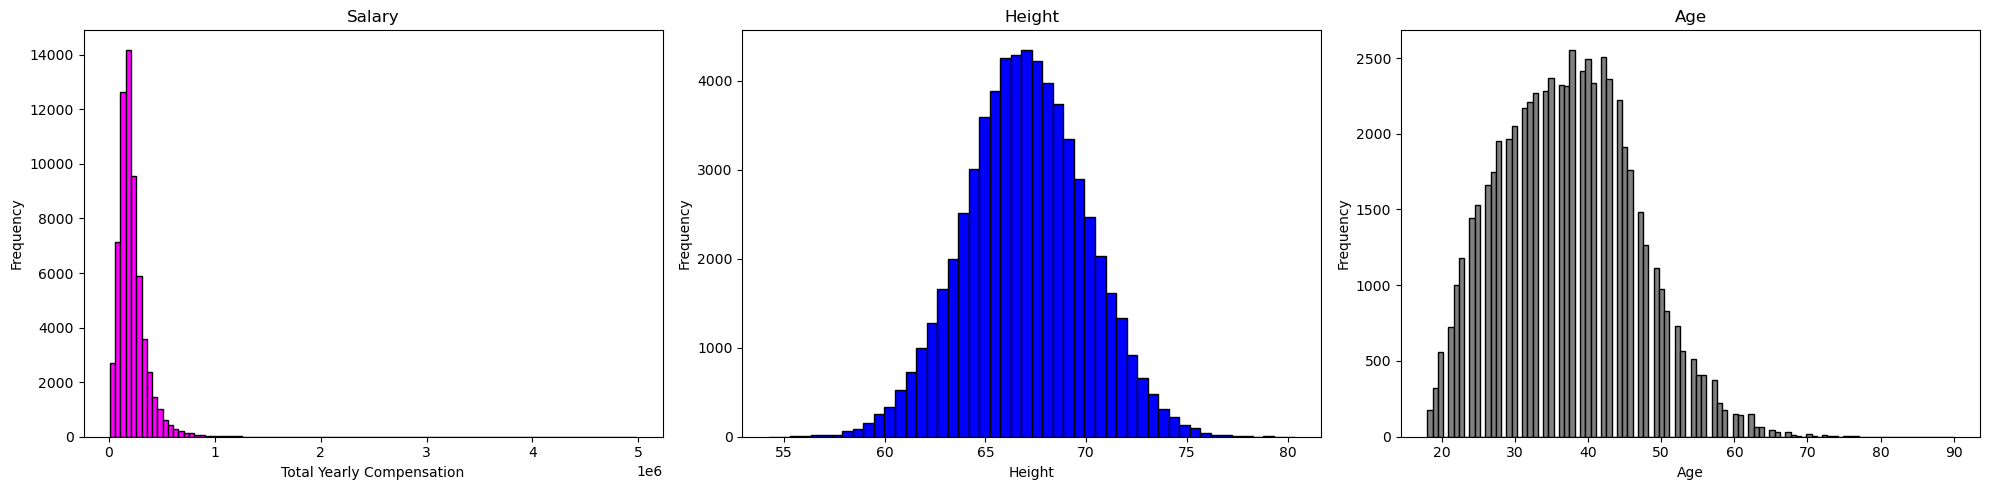



K^2 Test p-value: 0.0
The 'Salary' variable is not normally distributed (reject the null hypothesis)
K^2 Test p-value: 0.9886688374413325
The 'Height' variable is normally distributed (fail to reject the null hypothesis)
K^2 Test p-value: 2.519125683799389e-214
The 'Age' variable is not normally distributed (reject the null hypothesis)


In [7]:
# Extra Credit A

import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro, normaltest


data = pd.read_csv('techSalaries2017.csv')


salary = data['totalyearlycompensation']
height = data['Height']
age = data['Age']


plt.figure(figsize=(20, 5))

plt.subplot(1, 3, 1)
plt.hist(salary, bins= 100, color='magenta', edgecolor='black')
plt.title('Salary')
plt.xlabel('Total Yearly Compensation')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(height, bins= 50, color='blue', edgecolor='black')
plt.title('Height')
plt.xlabel('Height')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.hist(age, bins= 100, color='grey', edgecolor='black')
plt.title('Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("")
print("")
stat, p = normaltest(salary)
alpha = 0.05
print("K^2 Test p-value:", p)
if p < alpha:
    print("The 'Salary' variable is not normally distributed (reject the null hypothesis)")
else:
    print("The 'Salary' variable is normally distributed (fail to reject the null hypothesis)")

    
stat, p = normaltest(height)
alpha = 0.05
print("K^2 Test p-value:", p)
if p < alpha:
    print("The 'Height' variable is not normally distributed (reject the null hypothesis)")
else:
    print("The 'Height' variable is normally distributed (fail to reject the null hypothesis)")

    
stat, p = normaltest(age)
alpha = 0.05
print("K^2 Test p-value:", p)
if p < alpha:
    print("The 'Age' variable is not normally distributed (reject the null hypothesis)")
else:
    print("The 'Age' variable is normally distributed (fail to reject the null hypothesis)")



/var/folders/zw/3l_rthfn6vvdcc9kq0444wz40000gn/T/ipykernel_39616/176528950.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  required.dropna(inplace=True)


Correlation Matrix:
                              SAT       GPA  totalyearlycompensation
SAT                      1.000000  0.911969                 0.349972
GPA                      0.911969  1.000000                 0.319246
totalyearlycompensation  0.349972  0.319246                 1.000000


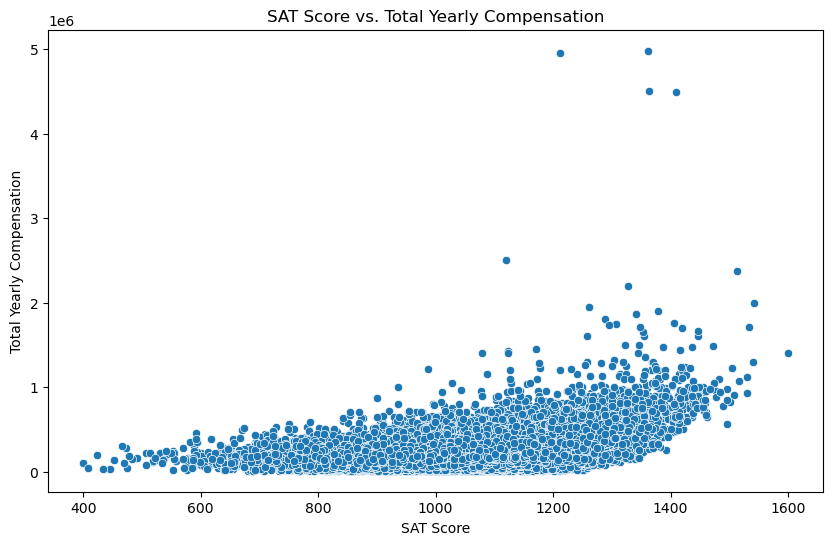

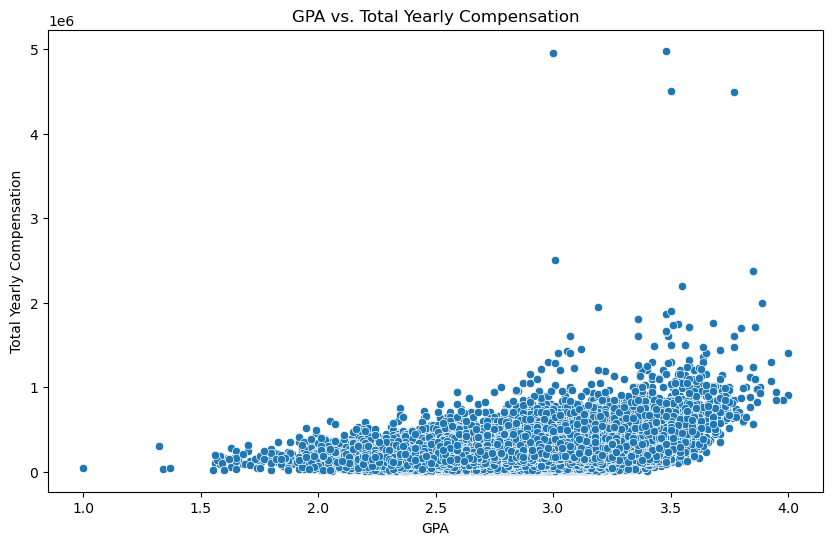

R-squared value: 0.12248018822270779


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

data = pd.read_csv('techSalaries2017.csv')

required = data[['SAT', 'GPA', 'totalyearlycompensation']]

required.dropna(inplace=True)

correlation_matrix = required.corr()
print("Correlation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='SAT', y='totalyearlycompensation', data=required)
plt.title('SAT Score vs. Total Yearly Compensation')
plt.xlabel('SAT Score')
plt.ylabel('Total Yearly Compensation')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x='GPA', y='totalyearlycompensation', data=required)
plt.title('GPA vs. Total Yearly Compensation')
plt.xlabel('GPA')
plt.ylabel('Total Yearly Compensation')
plt.show()

X = required[['SAT', 'GPA']]
y = required['totalyearlycompensation']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
print("R-squared value:", r2)